# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data.csv')

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

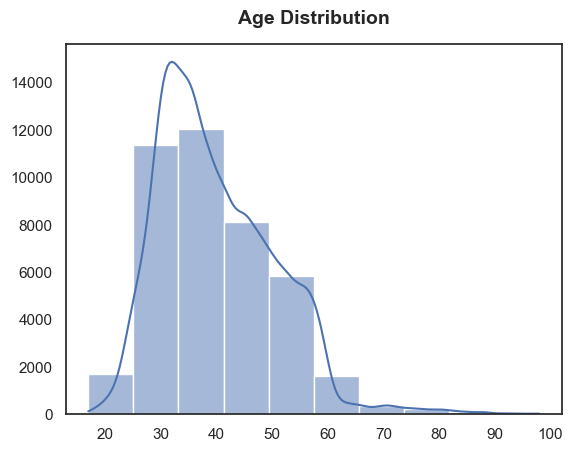

In [2]:
# Age distribution
sns.set_theme(style="white") 
sns.histplot(data = df, x = 'age', bins= 10, kde = True)
plt.title('Age Distribution', fontsize=14, pad=15, weight="bold")
plt.xlabel('')
plt.ylabel('')


plt.show()

## Observation
*Most customers are in the age range of 25-41*

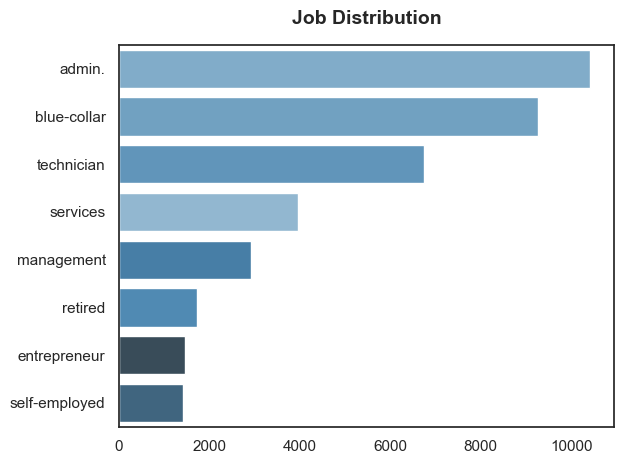

In [3]:
import matplotlib.ticker as ticker
# 1. Clean professional theme configuration
sns.set_theme(style="white")
# Job distribution

sns.countplot(data= df, y= 'job', palette="Blues_d", hue = "job", order= df['job'].value_counts().nlargest(8).index)
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

plt.xlabel("")
plt.ylabel("")
plt.title('Job Distribution', fontsize=14, pad=15, weight="bold")

plt.tight_layout()
# plt.savefig("job_dist.png", dpi= 600)
plt.show()

## Obeservation
*Top three most common Jobs of our customers are: Admin, Blue-collar, and Technician*

## Balance & Deposit Trends

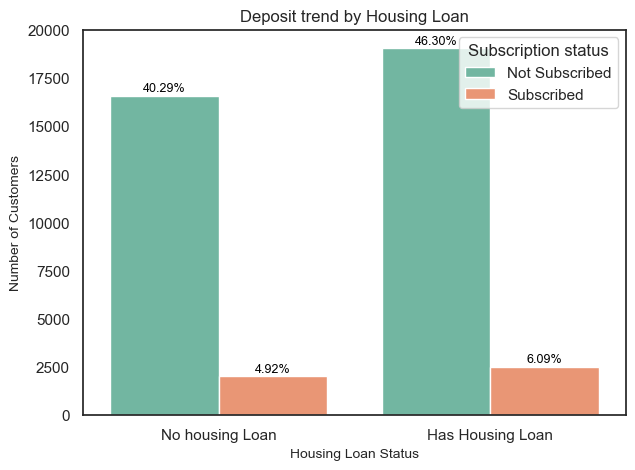

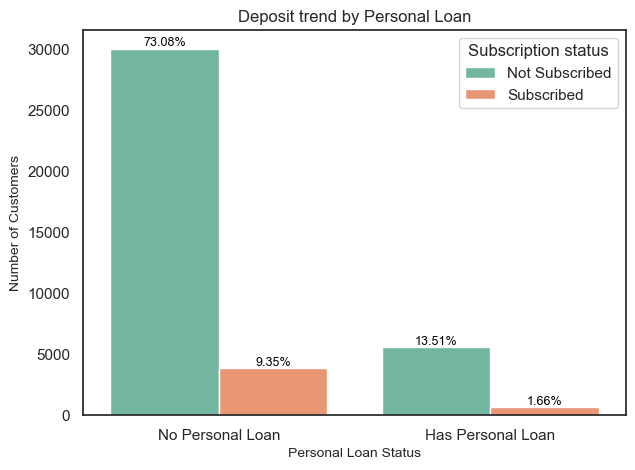

In [4]:
# Average balance by deposit subscription

# Renamed for better understanding
df['Subscription_Status'] = df['y'].map({'yes': 'Subscribed', 'no': 'Not Subscribed'})
df['Has_Housing_Loan'] = df['housing'].map({'yes': 'Has Housing Loan', 'no': 'No housing Loan'})

plt.figure(figsize=(7,5))

ax= sns.countplot(data= df, x='Has_Housing_Loan', hue= 'Subscription_Status', palette= 'Set2')
plt.title('Deposit trend by Housing Loan', fontsize= 12)
plt.xlabel('Housing Loan Status', fontsize= 10)
plt.ylabel('Number of Customers', fontsize= 10)
plt.legend(title= 'Subscription status')

# Calculating total number of rows in the dataset to get percentage base
total_customers = len(df)

for a in ax.patches:
    height = a.get_height() # Gets the height of the bar
    
    # Label bars
    if height > 0:
        percentage = (height / total_customers) * 100
        percentage_text = f'{percentage:.2f}%'
        
        ax.text(
            a.get_x() + a.get_width() / 2.,  # X position: center of the bar
            height + 200,                    # Y position: slightly above the bar height
            percentage_text,
            ha= "center",
            fontsize= 9,
            color= 'black'
        )
plt.show()

print('\n')

# For loan column
df['Has_Personal_Loan'] = df['loan'].map({'yes': 'Has Personal Loan', 'no': 'No Personal Loan'})
plt.figure(figsize=(7,5))

px= sns.countplot(data= df, x= 'Has_Personal_Loan', hue= 'Subscription_Status', palette= 'Set2')
plt.title('Deposit trend by Personal Loan', fontsize= 12)
plt.xlabel('Personal Loan Status', fontsize= 10)
plt.ylabel('Number of Customers', fontsize= 10)
plt.legend(title= 'Subscription status')

for p in px.patches:
    height= p.get_height()
    if height> 0:
        percentage = (height/ total_customers) *100
        percentage_text = f'{percentage:.2f}%'
        px.text(
            p.get_x() + p.get_width()/ 2.,
            height + 200,
            percentage_text,
            ha= 'center',
            fontsize= 9,
            color= 'black'
        )
plt.show()

# Observation

- *The prompt asked for Avarage of "balance," but since that column is not present in the dataset, I looked at housing and personal loans instead to see how existing debt impacts subscriptions to find Deposit Trends.*
  
- ### For Housing Loan:
  - *No Housing Loan: Roughly 2,000 "Yes" out of 18,500 total = ~11% said yes.*
  - *Has Housing Loan: Roughly 2,300 "Yes" out of 21,300 total = ~11% said yes.*
  - Conclusion: *Having a housing loan does not make someone more or less likely to subscribe.*
- ### For Personal Loan:
  - *No Personal Loan: ~3,800 "Yes" out of 33,800 total = ~11.2% said yes.*
  - *Has Personal Loan: ~500 "Yes" out of 6,000 total = ~8.3% said yes.*
  - Conclusion: *if someone is already paying off a personal loan, they are less likely to subscribe.*

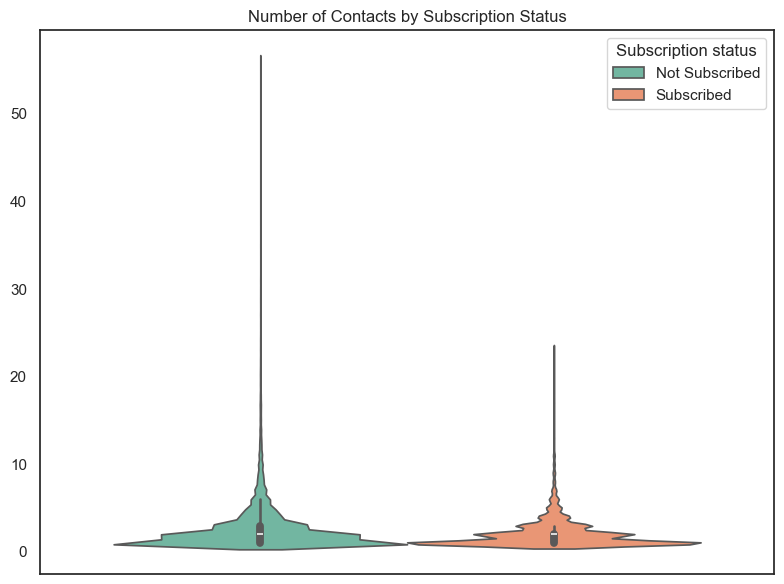

In [5]:
# Analyzing subscription status by how many times we contacted them (campaign)
sns.set_theme(style="white")
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, y='campaign', hue= 'Subscription_Status', palette='Set2')
plt.title('Number of Contacts by Subscription Status', fontsize= 12)
plt.xlabel("")
plt.ylabel("")
plt.legend(title= 'Subscription status')
plt.tight_layout()
# plt.savefig("ABTD_numberOFcont.png", dpi=600)
plt.show()

## Obeservation
*Calling a customer too many times does not help convert them; in fact, it likely annoys them. The highest chance of success is within the first few contact attempts (calls). If a customer hasn't subscribed after ~20 calls, continuing to call them is a waste of time and resources.*

## Campaign Effectiveness

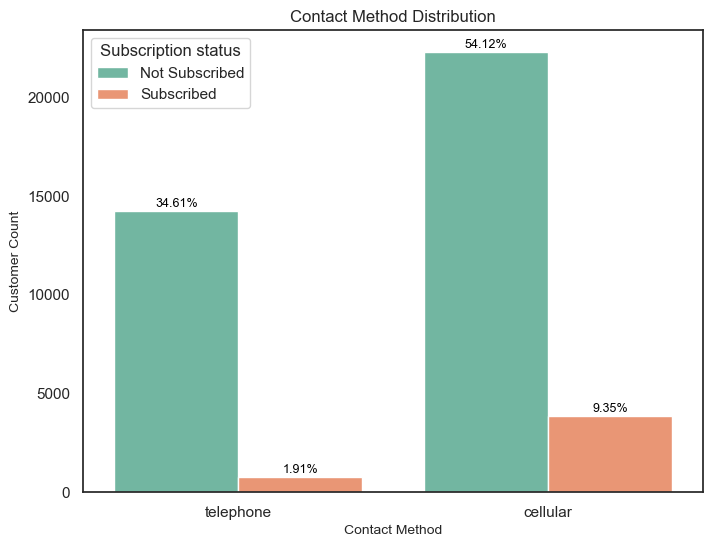

In [6]:
# Contact method analysis

plt.figure(figsize= (8,6))
cx = sns.countplot(data= df, x= 'contact', hue= 'Subscription_Status', palette= 'Set2')
plt.title('Contact Method Distribution', fontsize= 12)
plt.xlabel('Contact Method', fontsize= 10)
plt.ylabel('Customer Count', fontsize= 10)
plt.legend(title= 'Subscription status')
for c in cx.patches:
    height= c.get_height()
    if height> 0:
        percentage = (height/ total_customers) *100
        percentage_text = f'{percentage:.2f}%'
        cx.text(
            c.get_x() + c.get_width()/ 2.,
            height + 200,
            percentage_text,
            ha= 'center',
            fontsize= 9,
            color= 'black'
        )
plt.show()

## Obesrvation

- *Cellular: Roughly 3,800 "Yes" out of 26,000 total = ~14% said yes.*
- *Telephone: Roughly 400 "Yes" out of 15,000 total = ~2.5% said yes.*
- Conclusion: *Cellular contacts are far more effective. Customers are much more likely to subscribe when called on a mobile phone compared to a landline telephone.*

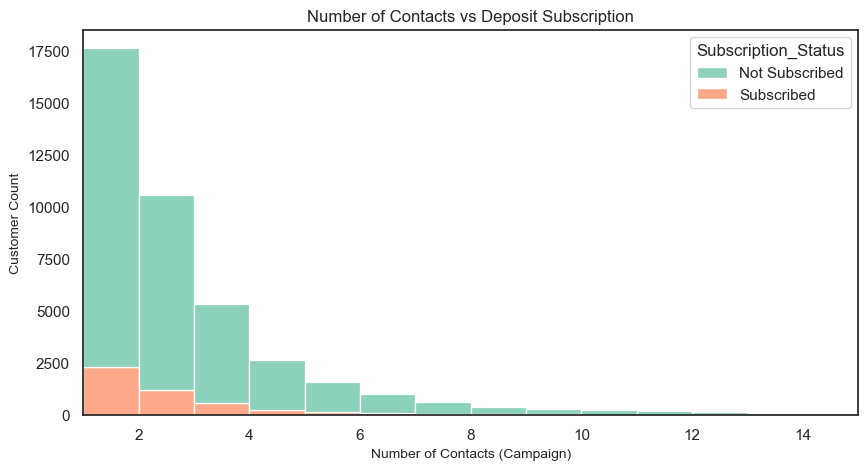

In [7]:
# Number of contacts vs deposit subscription


plt.figure(figsize=(10, 5))

sns.histplot(
    data=df, x='campaign', hue='Subscription_Status', multiple='stack', binwidth=1, palette='Set2')

plt.title('Number of Contacts vs Deposit Subscription', fontsize=12)
plt.xlabel('Number of Contacts (Campaign)', fontsize=10)
plt.ylabel('Customer Count', fontsize=10)


# Limit the x-axis to 15 so the extreme outliers don't stretch the graph too much
plt.xlim(1, 15)
plt.show()

## Observations

- *The highest number of subscriptions ("Subscribed" - orange) occurs on the very first contact attempt (x = 1).*
- *After the first contact, the number of successful subscriptions drops rapidly. By the 3rd, 4th, and subsequent contacts, almost everyone is unsubscribed (green).*
- Conclusion: *The campaign is highly front-loaded. Customers are most likely to say "yes" during the first call. Repeatedly contacting a customer multiple times yields heavily diminishing returns and wastes resources.*

## Correlation Heatmap

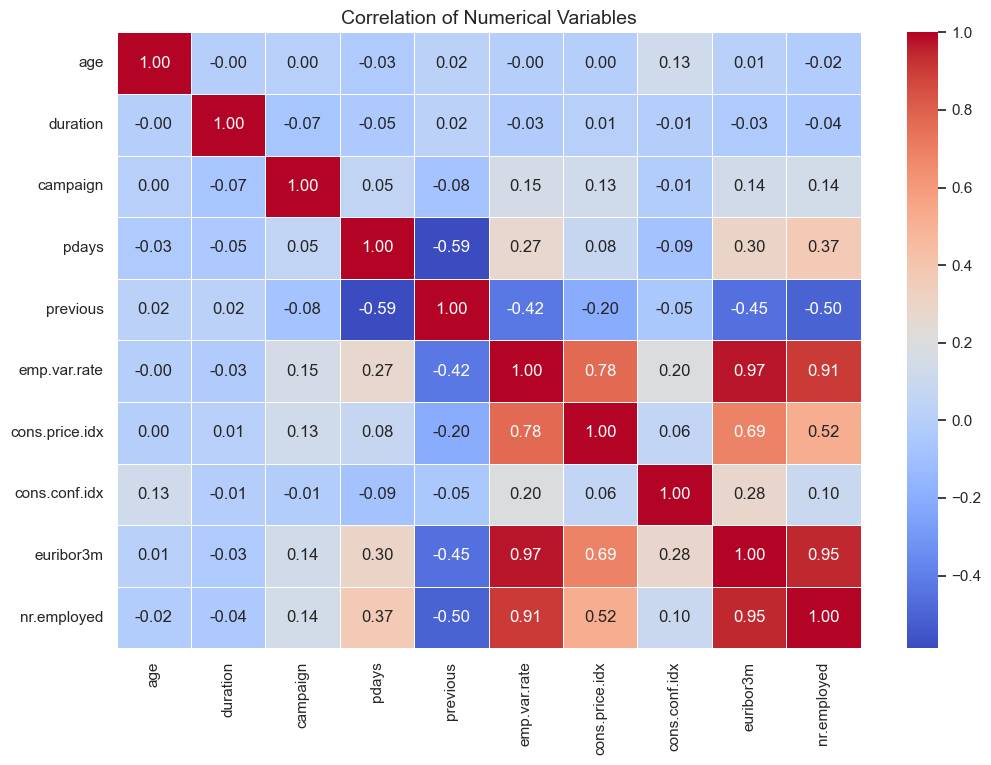

In [8]:
# Correlation of numerical variables


plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation of Numerical Variables', fontsize=14)
plt.show()

## Predictive Modeling (Logistic Regression)

Custom Model Accuracy: 80.71%

Classification Report:
              precision    recall  f1-score   support

          No       0.96      0.81      0.88      7310
         Yes       0.34      0.77      0.47       928

    accuracy                           0.81      8238
   macro avg       0.65      0.79      0.68      8238
weighted avg       0.89      0.81      0.84      8238



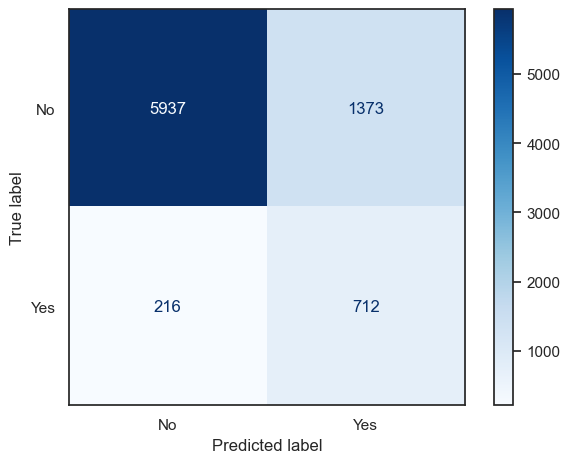

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Encode categorical variables

# Features and target
X = df[['age', 'job', 'marital', 'housing',
        'loan', 'contact', 'duration', 'campaign']]
y = df['y']

if y.dtype == 'object':
    y = y.map({'yes': 1, 'no': 0})

# Categorical and numerical columns
categorical_cols = ['job', 'marital', 'housing', 'loan', 'contact']
numeric_cols = ['age', 'duration', 'campaign']

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)


model = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(max_iter=10000, class_weight='balanced'))
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print(f"Custom Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap="Blues", values_format='d')
#plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("cofusion_matrix.png", dpi=600)
plt.show()


In [10]:
# Feature importance


logreg = model.named_steps['logreg']
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = logreg.coef_[0]


clean_names = []

for name in feature_names:
    name = name.replace('cat__', '')
    name = name.replace('remainder__', '')

    
    name = name.replace('_', ' ')
    name = name.title()

    clean_names.append(name)


coef_df = pd.DataFrame({
    'Feature': clean_names,
    'Coefficient': coefficients
})

# Top 10 most influential features


coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False).head(10)


coef_df = coef_df.sort_values('Coefficient')

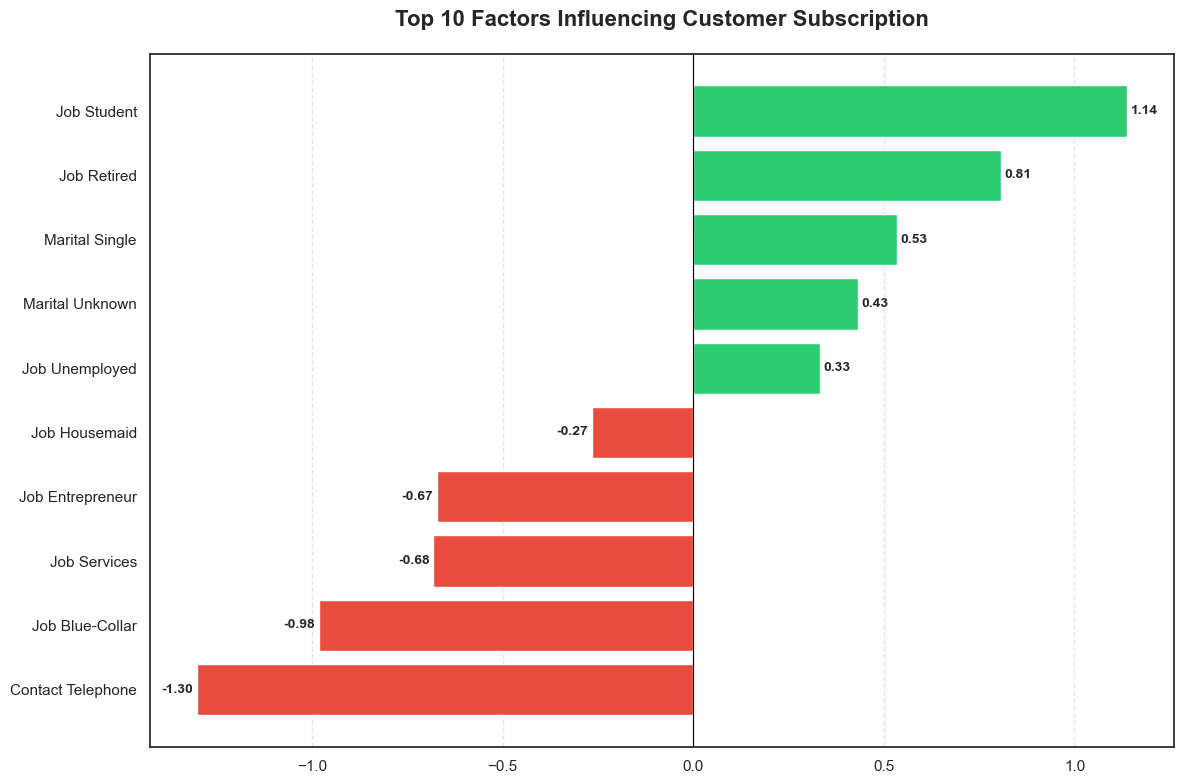

In [11]:

# Define colors: Green for positive, Red for negative
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coef_df['Coefficient']]

# Plotting
plt.figure(figsize=(12, 8))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

# Add values by the side of the bars
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + (0.01 if width > 0 else -0.01) # Small offset
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', 
             va='center', 
             ha='left' if width > 0 else 'right',
             fontsize=10, fontweight='bold')

# Styling
plt.axvline(x=0, color='black', linewidth=0.8) # Add a vertical line at 0
plt.title('Top 10 Factors Influencing Customer Subscription', fontsize=16, pad=20, weight="bold")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("Factors Influencing Customer Subscription.png", dpi= 600)
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.